<a href="https://colab.research.google.com/github/anshupandey/iimlddpm26/blob/main/IIMLDDPM_S2_flowboard_eda_graphs_plots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Analytics / Root Cause Analytics
## FlowBoard — SaaS Product Churn Analysis

---

## 1. Domain and Business Process Exploration

### Understanding the Business Domain

**FlowBoard** is a project management & collaboration SaaS platform (similar to Asana, Monday.com, Trello). Teams use it to plan sprints, manage tasks, automate workflows, and collaborate across functions.

**Recent industry context:**
- SaaS churn rates typically range from 3-8% monthly for SMB, 1-3% for Enterprise
- Product-led growth (PLG) models depend heavily on feature adoption driving upgrades
- AI-powered features (task suggestions, smart search) are becoming competitive differentiators
- The "aha moment" — when users discover core value — is critical for retention

### Business Process & Touchpoints

The FlowBoard customer journey:

| Stage | Touchpoint | Key Metric |
|-------|-----------|------------|
| **Acquisition** | Signup (Free tier) | New signups/day |
| **Activation** | First project created, first task completed | Time-to-value |
| **Engagement** | Feature usage, DAU/MAU | Stickiness ratio |
| **Revenue** | Free → Pro → Enterprise upgrade | Conversion rate |
| **Retention** | Continued active usage | Churn rate |
| **Referral** | NPS, invites sent | NPS score |

### Key Data Sources & Data Profile

| Source | What it contains | Format |
|--------|-----------------|--------|
| Product analytics | Feature usage events, session data | Event logs (CSV) |
| Billing system | Plan tier, signup date, upgrade history | User records |
| Customer feedback | NPS scores, support tickets, comments | Text + scores |
| Experiment platform | A/B test assignments and outcomes | Test results |
| KPI dashboard | Daily aggregated metrics | Time series |

### Our Objective

**Root cause analysis:** Why do FlowBoard users churn? Which user attributes, behaviors, and engagement patterns predict churn? What actionable recommendations can we make to the product team?

**Target variable:** `Churned` (binary: 1 = user inactive for 30+ days, 0 = active)


---

## 2. Data Collection & Exploration

We'll build a **user-level analytical dataset** by aggregating FlowBoard's event-level data into one row per user, then define our target variable (Churned).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Chart styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_palette(['#0891B2', '#F59E0B', '#94A3B8', '#DC2626', '#059669', '#8B5CF6'])

print("Libraries loaded successfully!")


Libraries loaded successfully!


In [2]:
# Load FlowBoard datasets
# events = pd.read_csv('flowboard_user_events.csv')
# kpis = pd.read_csv('flowboard_daily_kpis.csv')
# feedback = pd.read_csv('flowboard_customer_feedback.csv')
# ab_test = pd.read_csv('flowboard_ab_test.csv')


events = pd.read_csv('https://raw.githubusercontent.com/anshupandey/iimlddpm26/refs/heads/main/flowboard_user_events.csv')
prioritization = pd.read_csv('https://raw.githubusercontent.com/anshupandey/iimlddpm26/refs/heads/main/flowboard_feature_prioritization.csv')
ab_test = pd.read_csv('https://raw.githubusercontent.com/anshupandey/iimlddpm26/refs/heads/main/flowboard_ab_test.csv')
feedback = pd.read_csv('https://raw.githubusercontent.com/anshupandey/iimlddpm26/refs/heads/main/flowboard_customer_feedback.csv')
kpis = pd.read_csv('https://raw.githubusercontent.com/anshupandey/iimlddpm26/refs/heads/main/flowboard_daily_kpis.csv')


print("Datasets loaded:")
print(f"  Events:   {events.shape}")
print(f"  KPIs:     {kpis.shape}")
print(f"  Feedback: {feedback.shape}")
print(f"  A/B Test: {ab_test.shape}")


Datasets loaded:
  Events:   (3240, 6)
  KPIs:     (540, 6)
  Feedback: (150, 7)
  A/B Test: (2000, 7)


In [3]:
events.head()

,user_id,plan_tier,feature_name,usage_count,signup_date,last_active_date
0,U0241,Enterprise,Kanban Board,144,2025-03-30,2025-02-25
1,U0557,Free,Kanban Board,26,2025-03-01,2024-10-23
2,U0031,PRO,Kanban Board,12,2024-08-20,2025-02-04
3,U0526,Pro,API Access,17,2024-11-08,2025-03-31
4,U0218,Pro,Dark Mode,11,2024-12-31,2025-03-29


### Building the User-Level Analytical Dataset

We need to transform event-level data into **one row per user** with aggregated features, then create our **target column** (Churned).



In [4]:
# Step 1: Clean the events data first
# Fix inconsistent tier casing
tier_mapping = {
    'free': 'Free', 'FREE': 'Free',
    'pro': 'Pro', 'PRO': 'Pro',
    'enterprise': 'Enterprise', 'ENTERPRISE': 'Enterprise'
}
events['plan_tier'] = events['plan_tier'].replace(tier_mapping)

# Convert dates
events['signup_date'] = pd.to_datetime(events['signup_date'])
events['last_active_date'] = pd.to_datetime(events['last_active_date'])

print("Events data cleaned")
print(f"Plan tiers: {events['plan_tier'].unique()}")


Events data cleaned
Plan tiers: ['Enterprise' 'Free' 'Pro']


In [11]:
# Step 2: Aggregate to user level
# Get unique user profiles
user_profiles = events.groupby('user_id').agg(
    plan_tier=('plan_tier', 'first'),
    signup_date=('signup_date', 'first'),
    last_active_date=('last_active_date', 'first'),
).reset_index()

user_profiles.head()

,user_id,plan_tier,signup_date,last_active_date
0,U0001,Free,2025-02-27,2025-01-21
1,U0002,Enterprise,2025-02-02,2025-04-01
2,U0003,Pro,2025-02-25,2025-04-01
3,U0004,Pro,2025-03-16,2025-03-23
4,U0005,Free,2025-03-09,2025-02-27


In [12]:
signup_after_active_count = (user_profiles['signup_date'] > user_profiles['last_active_date']).sum()
print(f"Number of rows where signup_date is after last_active_date: {signup_after_active_count}")

Number of rows where signup_date is after last_active_date: 96


##### Data Cleaning: Correcting `signup_date` vs `last_active_date` Inconsistency

As observed earlier, there are instances where `signup_date` is later than `last_active_date`. This is logically incorrect. We will adjust `signup_date` to `last_active_date - 10 days` for these cases to ensure data consistency, assuming a user must have signed up before their last activity. This correction will be applied to the `user_profiles` DataFrame before it's merged into `df`.

In [ ]:
# Identify rows in user_profiles where signup_date is after last_active_date
inconsistent_dates_mask_user_profiles = user_profiles['signup_date'] > user_profiles['last_active_date']

# Count before correction (already done in previous cell, but re-confirming here for context)
count_before_correction = inconsistent_dates_mask_user_profiles.sum()
print(f"Number of inconsistent dates in user_profiles before correction: {count_before_correction}")

# Correct the signup_date for inconsistent rows in user_profiles
user_profiles.loc[inconsistent_dates_mask_user_profiles, 'signup_date'] = \
    user_profiles.loc[inconsistent_dates_mask_user_profiles, 'last_active_date'] - pd.Timedelta(days=10)

# Verify the correction
count_after_correction = (user_profiles['signup_date'] > user_profiles['last_active_date']).sum()
print(f"Number of inconsistent dates in user_profiles after correction: {count_after_correction}")
print("signup_date in user_profiles has been corrected for inconsistent records.")


In [14]:
# Feature usage metrics per user
user_features = events.groupby('user_id').agg(
    num_features_used=('feature_name', 'nunique'),
    total_usage=('usage_count', 'sum'),
    avg_usage_per_feature=('usage_count', 'mean'),
    max_usage_single_feature=('usage_count', 'max'),
).reset_index()

user_features.head()

,user_id,num_features_used,total_usage,avg_usage_per_feature,max_usage_single_feature
0,U0001,2,22,11.000000,16
1,U0002,9,1203,133.666667,368
2,U0003,4,74,18.500000,24
3,U0004,6,304,50.666667,151
4,U0005,2,52,26.000000,27


In [15]:
# Specific feature flags (did user use these key features?)
key_features = ['Automations', 'Smart Search', 'Export Reports', 'API Access',
                'Dashboard Widgets', 'Gantt Charts', 'Team Chat', 'Dark Mode']

for feat in key_features:
    feat_users = events[events['feature_name'] == feat]['user_id'].unique()
    col_name = 'uses_' + feat.lower().replace(' ', '_')
    user_profiles[col_name] = user_profiles['user_id'].isin(feat_users).astype(int)

# Merge
df = user_profiles.merge(user_features, on='user_id', how='left')

print(f"User-level dataset: {df.shape}")
df.head()

User-level dataset: (600, 16)


,user_id,plan_tier,signup_date,last_active_date,uses_automations,uses_smart_search,uses_export_reports,uses_api_access,uses_dashboard_widgets,uses_gantt_charts,uses_team_chat,uses_dark_mode,num_features_used,total_usage,avg_usage_per_feature,max_usage_single_feature
0,U0001,Free,2025-01-11,2025-01-21,0,0,0,0,0,0,1,0,2,22,11.000000,16
1,U0002,Enterprise,2025-02-02,2025-04-01,0,1,1,0,1,1,1,0,9,1203,133.666667,368
2,U0003,Pro,2025-02-25,2025-04-01,0,0,1,0,0,1,0,0,4,74,18.500000,24
3,U0004,Pro,2025-03-16,2025-03-23,0,0,1,0,1,0,1,1,6,304,50.666667,151
4,U0005,Free,2025-02-17,2025-02-27,0,0,0,0,0,0,1,0,2,52,26.000000,27


In [16]:
# Step 3: Engineer additional features
reference_date = pd.Timestamp('2025-04-01')

# Account age in days
df['account_age_days'] = (reference_date - df['signup_date']).dt.days

# Days since last active
df['days_since_active'] = (reference_date - df['last_active_date']).dt.days

# Account age in months (for tenure)
df['tenure_months'] = (df['account_age_days'] / 30).round(0).astype(int)

# Usage intensity (total usage / account age)
df['usage_intensity'] = (df['total_usage'] / df['account_age_days'].clip(lower=1)).round(2)

# Feature breadth ratio (features used / total features available = 12)
df['feature_breadth'] = (df['num_features_used'] / 12).round(3)

print("Features engineered:")
print(df.columns.tolist())


Features engineered:
['user_id', 'plan_tier', 'signup_date', 'last_active_date', 'uses_automations', 'uses_smart_search', 'uses_export_reports', 'uses_api_access', 'uses_dashboard_widgets', 'uses_gantt_charts', 'uses_team_chat', 'uses_dark_mode', 'num_features_used', 'total_usage', 'avg_usage_per_feature', 'max_usage_single_feature', 'account_age_days', 'days_since_active', 'tenure_months', 'usage_intensity', 'feature_breadth']


In [17]:
# Step 4: Create the TARGET variable — Churned
# Definition: User is "Churned" if inactive for 30+ days
df['Churned'] = (df['days_since_active'] >= 30).astype(int)

print(f"\nTarget variable created: Churned")
print(f"  Active (0): {(df['Churned']==0).sum()} ({(df['Churned']==0).mean():.1%})")
print(f"  Churned (1): {(df['Churned']==1).sum()} ({(df['Churned']==1).mean():.1%})")



Target variable created: Churned
  Active (0): 391 (65.2%)
  Churned (1): 209 (34.8%)


In [18]:
# Step 5: Add feedback data (NPS) where available
avg_nps = feedback.groupby('customer_id')['nps_score'].mean().reset_index()
avg_nps.columns = ['user_id', 'nps_score']
df = df.merge(avg_nps, on='user_id', how='left')

# Fill NPS for users without feedback with median
df['nps_score'] = df['nps_score'].fillna(df['nps_score'].median())

# NPS category
df['nps_category'] = pd.cut(df['nps_score'], bins=[0, 6, 8, 10],
                             labels=['Detractor', 'Passive', 'Promoter'])

print(f"Final dataset: {df.shape}")
print(f"Columns: {len(df.columns)}")


Final dataset: (600, 24)
Columns: 24


In [19]:
# Drop helper columns, keep analytical features
cols_to_drop = ['user_id', 'signup_date', 'last_active_date', 'days_since_active']
df.drop(columns=cols_to_drop, inplace=True)

print("Final analytical dataset:")
df.shape


Final analytical dataset:


(600, 20)

In [20]:
df.head()


,plan_tier,uses_automations,uses_smart_search,uses_export_reports,uses_api_access,uses_dashboard_widgets,uses_gantt_charts,uses_team_chat,uses_dark_mode,num_features_used,total_usage,avg_usage_per_feature,max_usage_single_feature,account_age_days,tenure_months,usage_intensity,feature_breadth,Churned,nps_score,nps_category
0,Free,0,0,0,0,0,0,1,0,2,22,11.000000,16,80,3,0.28,0.167,1,3.0,Detractor
1,Enterprise,0,1,1,0,1,1,1,0,9,1203,133.666667,368,58,2,20.74,0.750,0,5.0,Detractor
2,Pro,0,0,1,0,0,1,0,0,4,74,18.500000,24,35,1,2.11,0.333,0,5.0,Detractor
3,Pro,0,0,1,0,1,0,1,1,6,304,50.666667,151,16,1,19.00,0.500,0,5.0,Detractor
4,Free,0,0,0,0,0,0,1,0,2,52,26.000000,27,43,1,1.21,0.167,1,5.0,Detractor


In [21]:
df.describe()


,uses_automations,uses_smart_search,uses_export_reports,uses_api_access,uses_dashboard_widgets,uses_gantt_charts,uses_team_chat,uses_dark_mode,num_features_used,total_usage,avg_usage_per_feature,max_usage_single_feature,account_age_days,tenure_months,usage_intensity,feature_breadth,Churned,nps_score
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.00000,600.000000,600.000000
mean,0.315000,0.460000,0.398333,0.175000,0.358333,0.250000,0.690000,0.545000,5.400000,328.931667,48.796366,135.365000,177.361667,5.928333,5.147767,0.45001,0.348333,5.086667
std,0.464903,0.498813,0.489963,0.380284,0.479911,0.433374,0.462879,0.498386,2.656142,369.207097,41.383197,153.696865,145.781989,4.829984,15.451014,0.22132,0.476840,0.954292
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000,2.000000,2.000000,3.000000,0.000000,0.010000,0.08300,0.000000,2.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,61.000000,18.500000,32.750000,62.750000,2.000000,0.410000,0.25000,0.000000,5.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,5.000000,175.000000,36.262500,78.500000,133.000000,4.000000,1.370000,0.41700,0.000000,5.000000
75%,1.000000,1.000000,1.000000,0.000000,1.000000,0.250000,1.000000,1.000000,8.000000,476.500000,64.500000,170.500000,247.250000,8.000000,3.995000,0.66700,1.000000,5.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1994.000000,249.250000,904.000000,548.000000,18.000000,289.000000,1.00000,1.000000,10.000000


In [22]:
df.describe(include='all')


,plan_tier,uses_automations,uses_smart_search,uses_export_reports,uses_api_access,uses_dashboard_widgets,uses_gantt_charts,uses_team_chat,uses_dark_mode,num_features_used,total_usage,avg_usage_per_feature,max_usage_single_feature,account_age_days,tenure_months,usage_intensity,feature_breadth,Churned,nps_score,nps_category
count,600,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.00000,600.000000,600.000000,600
unique,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,Free,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Detractor
freq,264,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,571
mean,NaN,0.315000,0.460000,0.398333,0.175000,0.358333,0.250000,0.690000,0.545000,5.400000,328.931667,48.796366,135.365000,177.361667,5.928333,5.147767,0.45001,0.348333,5.086667,NaN
std,NaN,0.464903,0.498813,0.489963,0.380284,0.479911,0.433374,0.462879,0.498386,2.656142,369.207097,41.383197,153.696865,145.781989,4.829984,15.451014,0.22132,0.476840,0.954292,NaN
min,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000,2.000000,2.000000,3.000000,0.000000,0.010000,0.08300,0.000000,2.000000,NaN
25%,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,61.000000,18.500000,32.750000,62.750000,2.000000,0.410000,0.25000,0.000000,5.000000,NaN
50%,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,5.000000,175.000000,36.262500,78.500000,133.000000,4.000000,1.370000,0.41700,0.000000,5.000000,NaN
75%,NaN,1.000000,1.000000,1.000000,0.000000,1.000000,0.250000,1.000000,1.000000,8.000000,476.500000,64.500000,170.500000,247.250000,8.000000,3.995000,0.66700,1.000000,5.000000,NaN


### Observations from Initial Exploration

**Column Categories:**

- **Demographics/Account:** `plan_tier`, `tenure_months`, `account_age_days`
- **Feature Adoption:** `num_features_used`, `uses_automations`, `uses_smart_search`, `uses_export_reports`, `uses_api_access`, `uses_dashboard_widgets`, `uses_gantt_charts`, `uses_team_chat`, `uses_dark_mode`
- **Usage Intensity:** `total_usage`, `avg_usage_per_feature`, `max_usage_single_feature`, `usage_intensity`, `feature_breadth`
- **Satisfaction:** `nps_score`, `nps_category`
- **Target:** `Churned`

**Initial signals:**
- The dataset has a mix of numeric and categorical features — good for diverse analysis
- `plan_tier` is analogous to `Geography` — a categorical segmentation variable
- `Churned` is our target


---

## 3. Data Cleaning


In [23]:
# Check for duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")


Duplicate rows: 0


In [24]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
plan_tier                   0
uses_automations            0
uses_smart_search           0
uses_export_reports         0
uses_api_access             0
uses_dashboard_widgets      0
uses_gantt_charts           0
uses_team_chat              0
uses_dark_mode              0
num_features_used           0
total_usage                 0
avg_usage_per_feature       0
max_usage_single_feature    0
account_age_days            0
tenure_months               0
usage_intensity             0
feature_breadth             0
Churned                     0
nps_score                   0
nps_category                0
dtype: int64


In [25]:
# Check for outliers using skewness
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('Churned')  # exclude target

print("Skewness of numeric columns:")
print(df[numeric_cols].skew().round(4))


Skewness of numeric columns:
uses_automations             0.7985
uses_smart_search            0.1609
uses_export_reports          0.4164
uses_api_access              1.7150
uses_dashboard_widgets       0.5924
uses_gantt_charts            1.1576
uses_team_chat              -0.8237
uses_dark_mode              -0.1812
num_features_used            0.3488
total_usage                  1.5424
avg_usage_per_feature        1.5062
max_usage_single_feature     2.1010
account_age_days             1.0987
tenure_months                1.0890
usage_intensity             12.0042
feature_breadth              0.3490
nps_score                    2.2099
dtype: float64


In [26]:
# Handle outliers for highly skewed columns (skew > 1.5)
skewed = df[numeric_cols].skew()
high_skew_cols = skewed[abs(skewed) > 1.5].index.tolist()
print(f"Highly skewed columns: {high_skew_cols}")

for col in high_skew_cols:
    upper = df[col].quantile(0.97)
    df.loc[df[col] > upper, col] = upper
    print(f"  {col}: capped at {upper:.2f}, new skew = {df[col].skew():.4f}")


Highly skewed columns: ['uses_api_access', 'total_usage', 'avg_usage_per_feature', 'max_usage_single_feature', 'usage_intensity', 'nps_score']
  uses_api_access: capped at 1.00, new skew = 1.7150
  total_usage: capped at 1204.50, new skew = 1.2514
  avg_usage_per_feature: capped at 149.46, new skew = 1.1246
  max_usage_single_feature: capped at 542.87, new skew = 1.5893
  usage_intensity: capped at 30.09, new skew = 2.5069
  nps_score: capped at 8.00, new skew = 1.1274


In [27]:
# Identify numeric and categorical columns for analysis
nums = ['tenure_months', 'num_features_used', 'total_usage', 'avg_usage_per_feature',
        'max_usage_single_feature', 'usage_intensity', 'feature_breadth',
        'account_age_days', 'nps_score']

cats = ['plan_tier', 'uses_automations', 'uses_smart_search', 'uses_export_reports',
        'uses_api_access', 'uses_dashboard_widgets', 'uses_gantt_charts',
        'uses_team_chat', 'uses_dark_mode', 'nps_category']

print(f"Numeric features ({len(nums)}): {nums}")
print(f"Categorical features ({len(cats)}): {cats}")
print(f"Target: Churned")


Numeric features (9): ['tenure_months', 'num_features_used', 'total_usage', 'avg_usage_per_feature', 'max_usage_single_feature', 'usage_intensity', 'feature_breadth', 'account_age_days', 'nps_score']
Categorical features (10): ['plan_tier', 'uses_automations', 'uses_smart_search', 'uses_export_reports', 'uses_api_access', 'uses_dashboard_widgets', 'uses_gantt_charts', 'uses_team_chat', 'uses_dark_mode', 'nps_category']
Target: Churned


---

## 4. Exploratory Analytics / Root Cause Analytics

### Data Visualization Approach
- **Univariate Analysis:** analyzing one variable at a time
- **Bivariate Analysis:** analyzing each variable with the target (Churned)
- **Multivariate Analysis:** analyzing multiple attributes together

### Statistical Exploration Approach
- **Univariate:** variance analysis
- **Bivariate:** correlation analysis
- **Hypothesis Testing:** ANOVA, Chi-Square test

---

### 4.1 Univariate Analysis

Analyzing one variable at a time:
- **Numeric:** Continuous frequency distribution → Histograms
- **Categorical:** Discrete frequency distribution → Bar plots


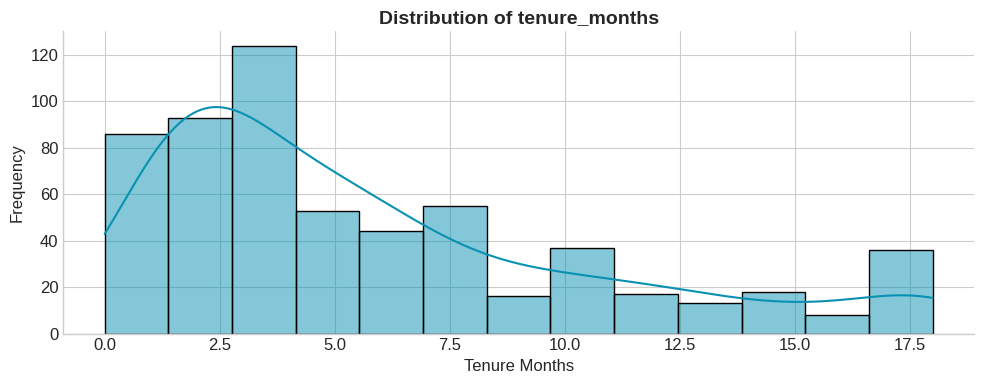

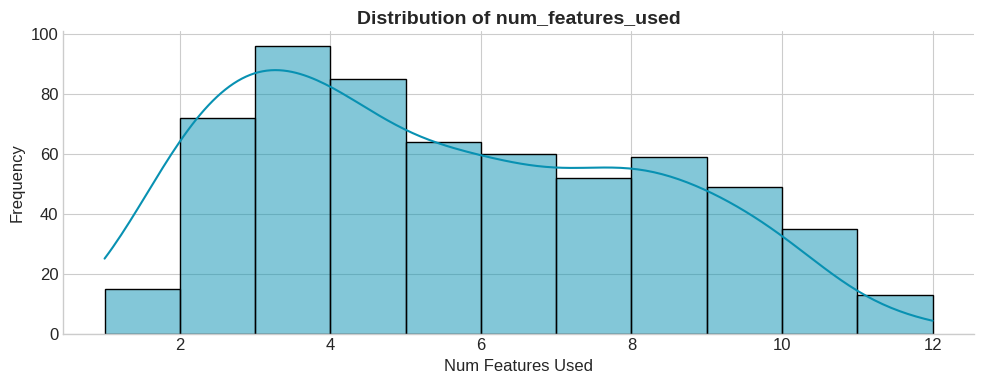

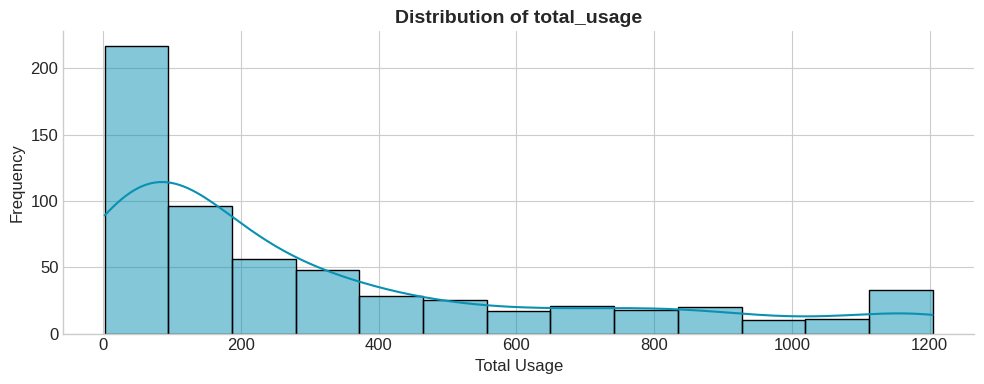

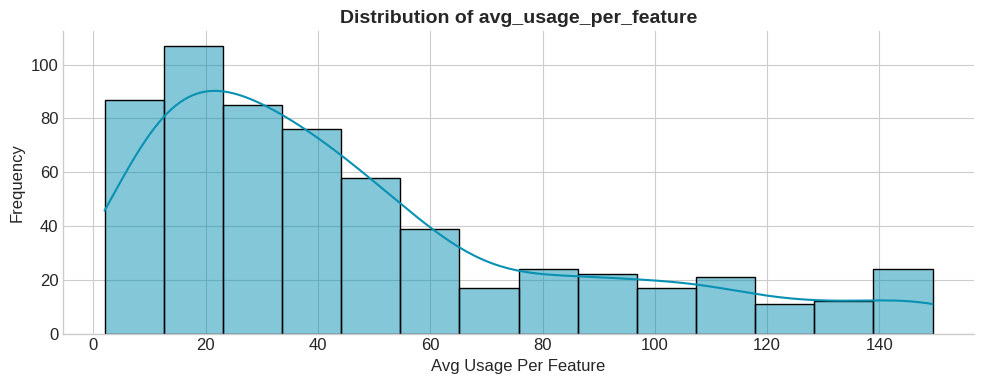

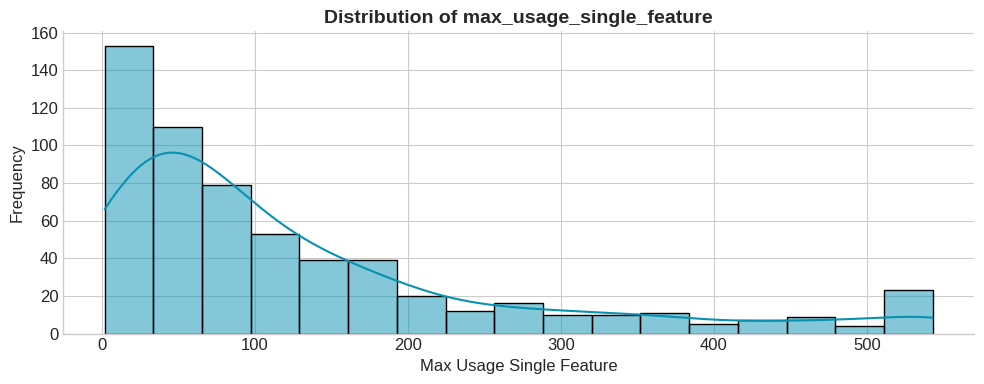

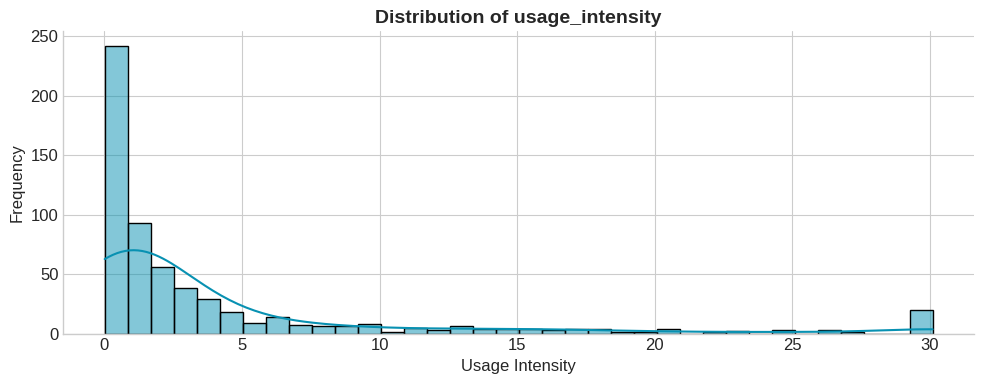

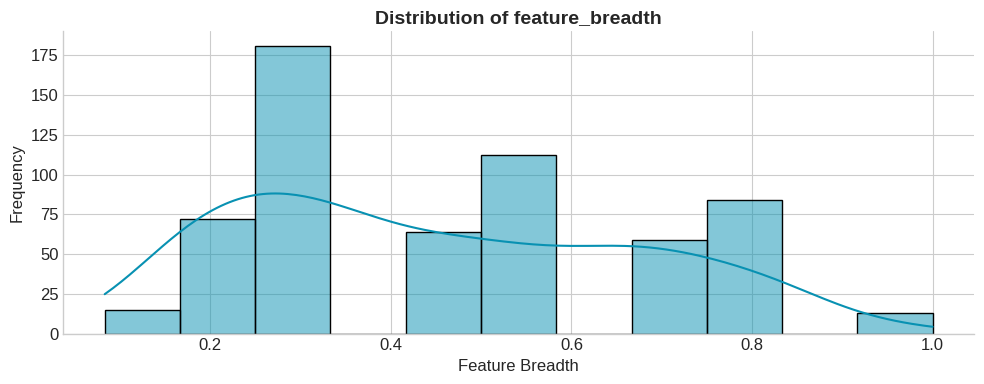

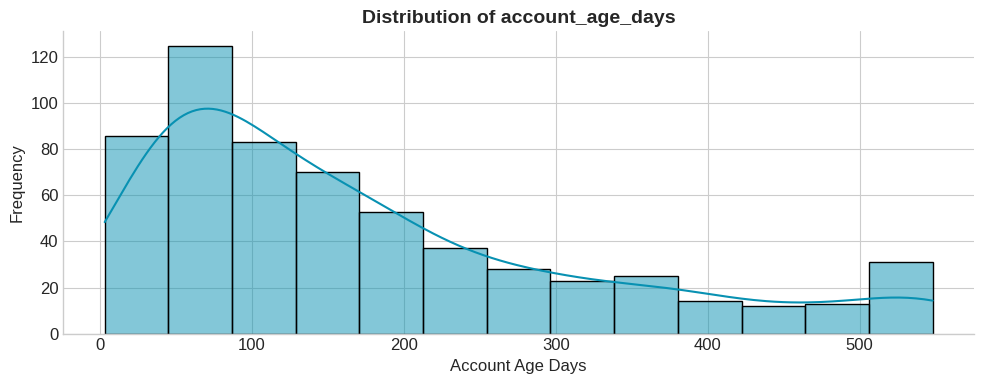

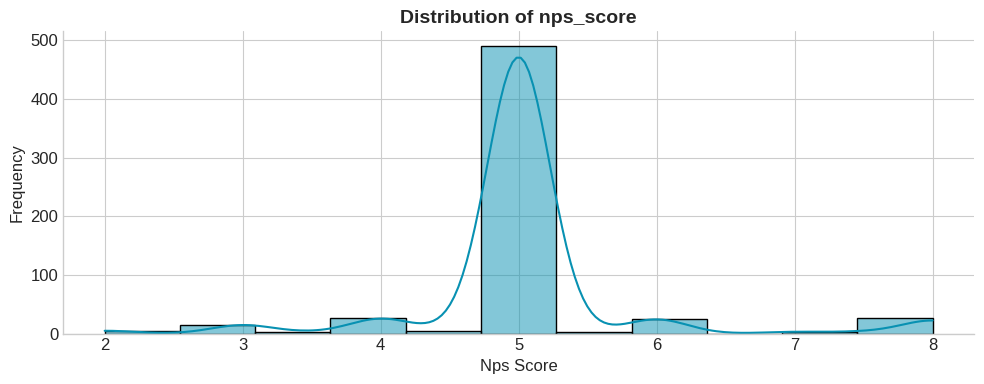

In [28]:
# Univariate: Histograms for all numeric columns
for column in nums:
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.histplot(df[column], kde=True, ax=ax, color='#0891B2')
    ax.set_title(f'Distribution of {column}', fontsize=14, fontweight='bold')
    ax.set_xlabel(column.replace('_', ' ').title())
    ax.set_ylabel('Frequency')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

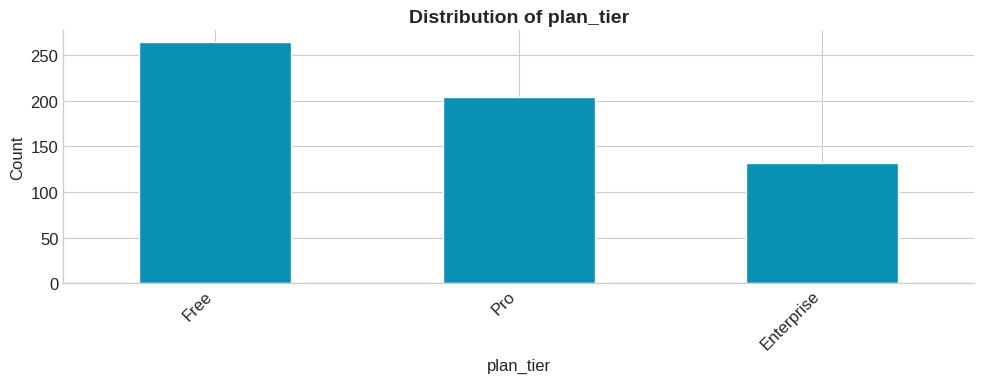

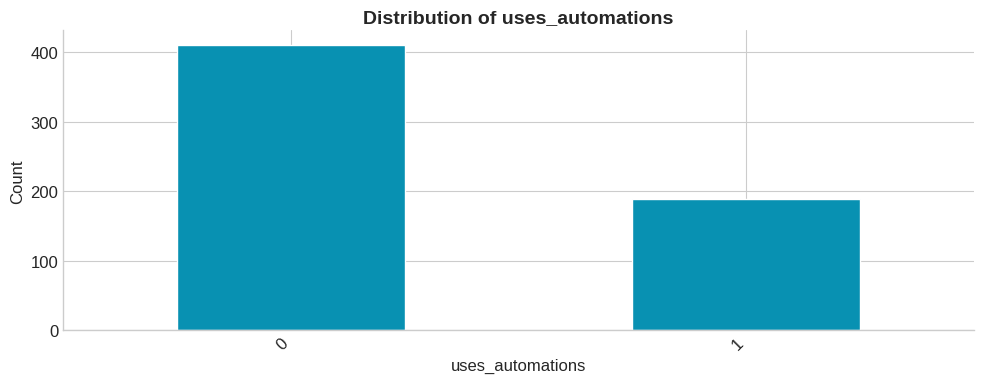

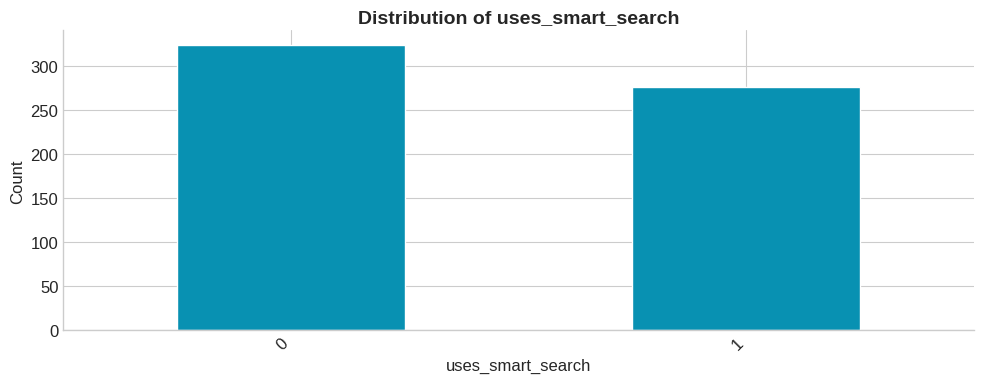

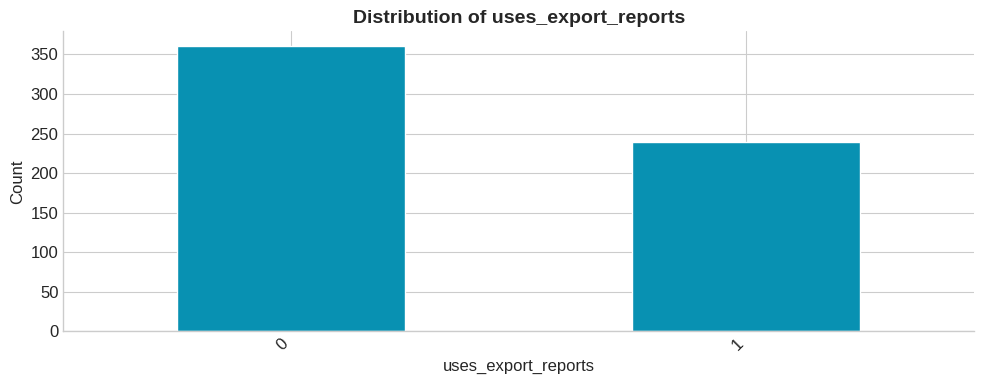

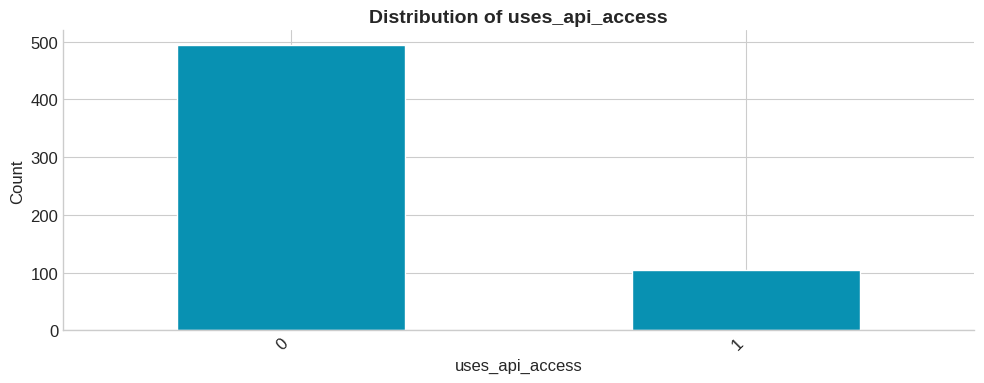

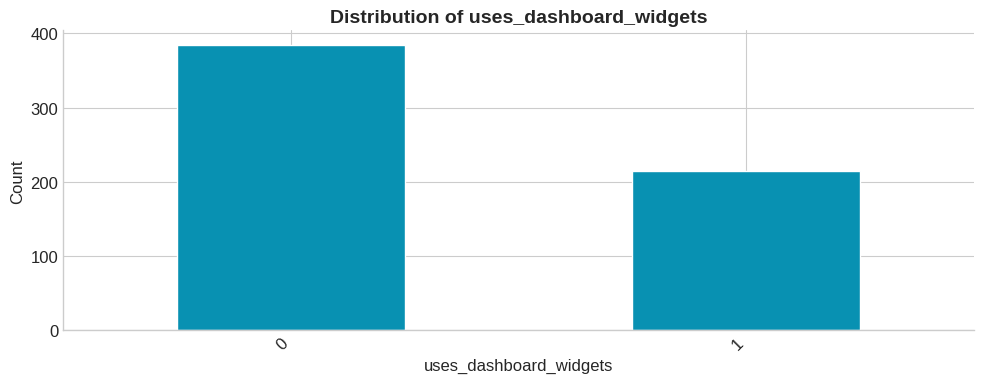

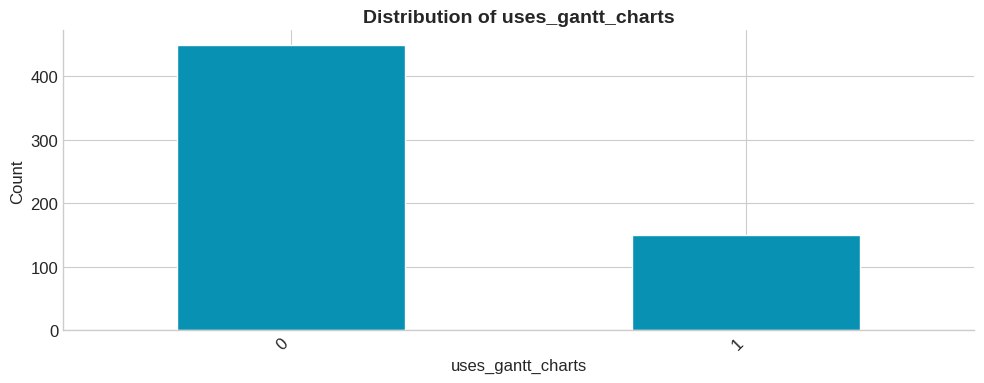

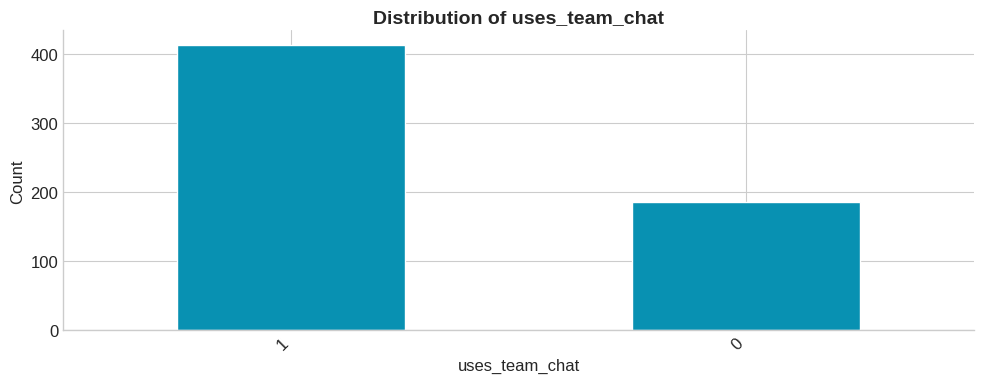

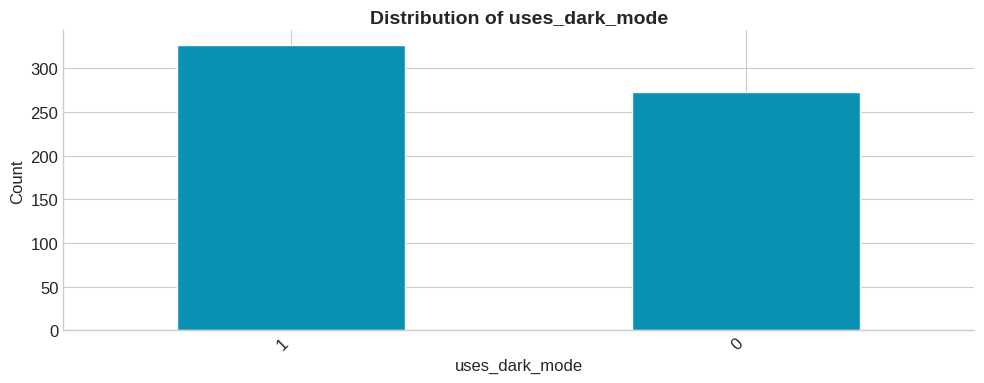

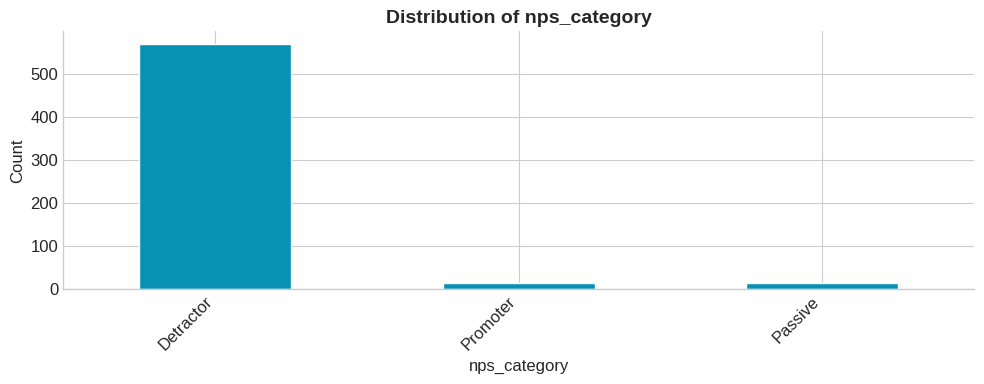

In [29]:
# Univariate: Bar plots for all categorical columns
for column in cats:
    fig, ax = plt.subplots(figsize=(10, 4))
    df[column].value_counts().plot(kind='bar', color='#0891B2', edgecolor='white', ax=ax)
    ax.set_title(f'Distribution of {column}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Count')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


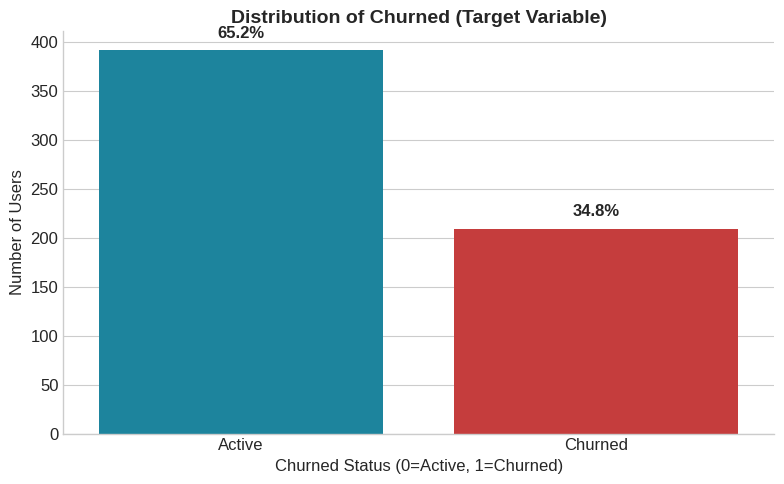

In [30]:
# Target variable distribution
churn_counts = df['Churned'].value_counts()
churn_percentage = df['Churned'].value_counts(normalize=True).mul(100).round(1)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=churn_counts.index, y=churn_counts.values, ax=ax, palette=['#0891B2', '#DC2626'])

# Add title and labels
ax.set_title('Distribution of Churned (Target Variable)', fontsize=14, fontweight='bold')
ax.set_xlabel('Churned Status (0=Active, 1=Churned)')
ax.set_ylabel('Number of Users')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Active', 'Churned'])

# Add percentages on top of the bars
for i, (count, percentage) in enumerate(zip(churn_counts.values, churn_percentage.values)):
    ax.text(i, count + 10, f'{percentage}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### Univariate Observations

Record your observations here after running the cells above:

- **tenure_months:** Distribution shape? Range?
- **num_features_used:** How many features do most users adopt?
- **total_usage:** Is it skewed? Power users vs casual?
- **usage_intensity:** How actively do users engage per day?
- **feature_breadth:** What fraction of the product do users explore?
- **nps_score:** Sentiment distribution?
- **plan_tier:** Which tier dominates?
- **Feature adoption flags:** Which features have highest/lowest adoption?
- **Churned:** What is the churn rate? (Compare to industry benchmarks: 3-8% monthly for SaaS)

---

### 4.2 Bivariate Analysis

Analyzing each variable with the target column (**Churned**: categorical)

- **Numeric vs Categorical (target):** Overlaid distribution plots (histplot/kdeplot)
- **Categorical vs Categorical (target):** Cross-tabulation with bar charts
- **Numeric vs Numeric:** Scatter plots


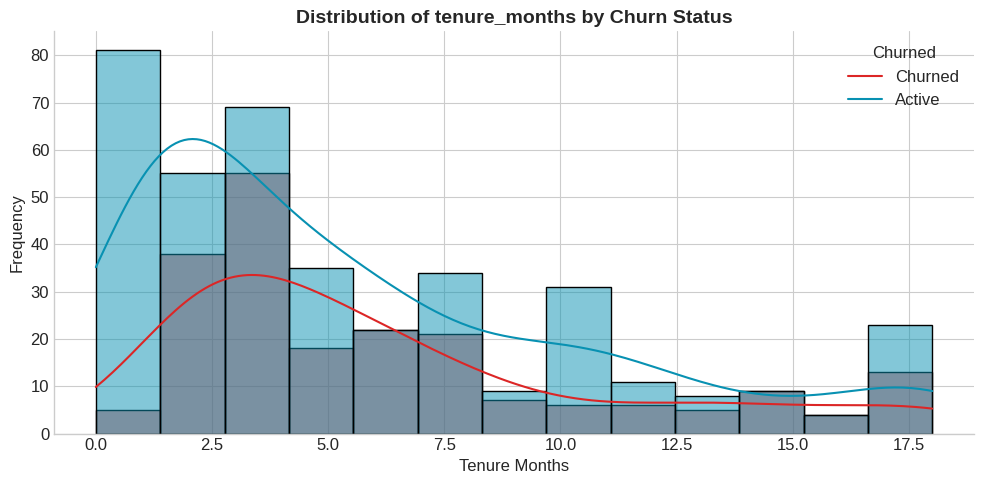

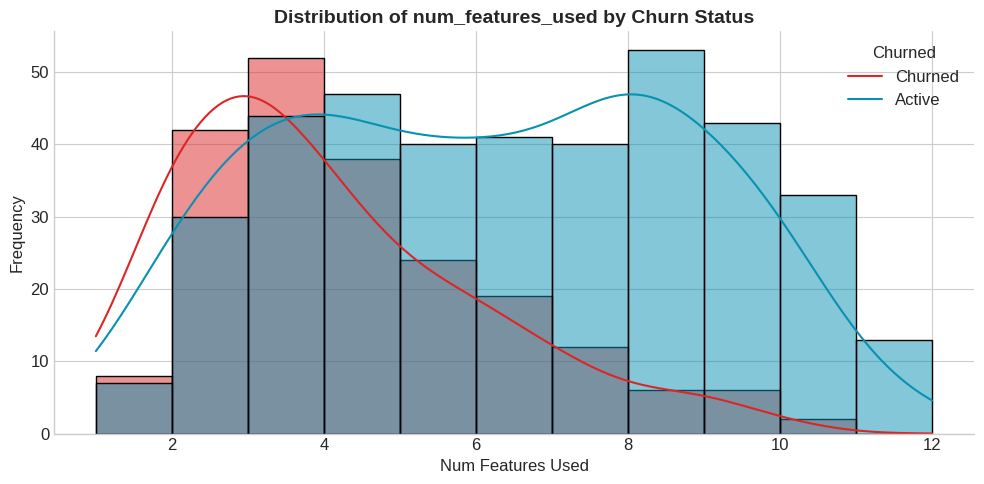

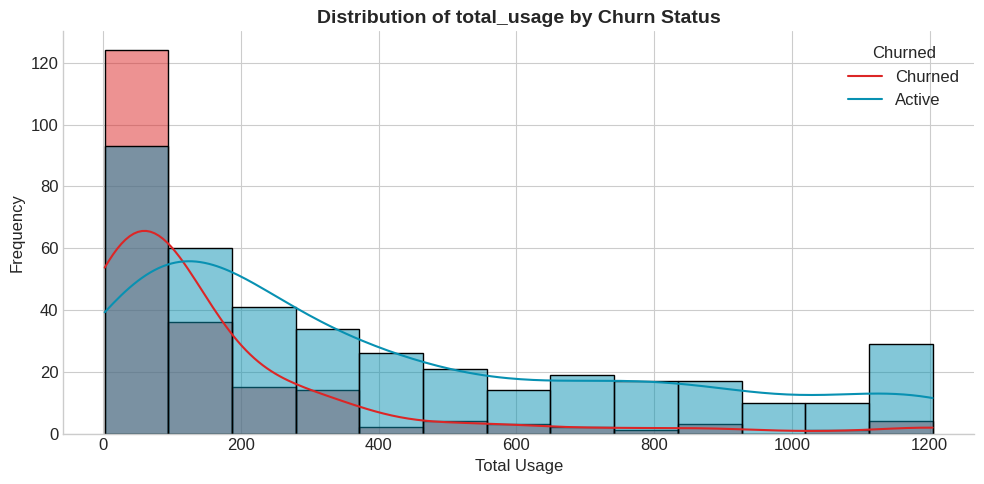

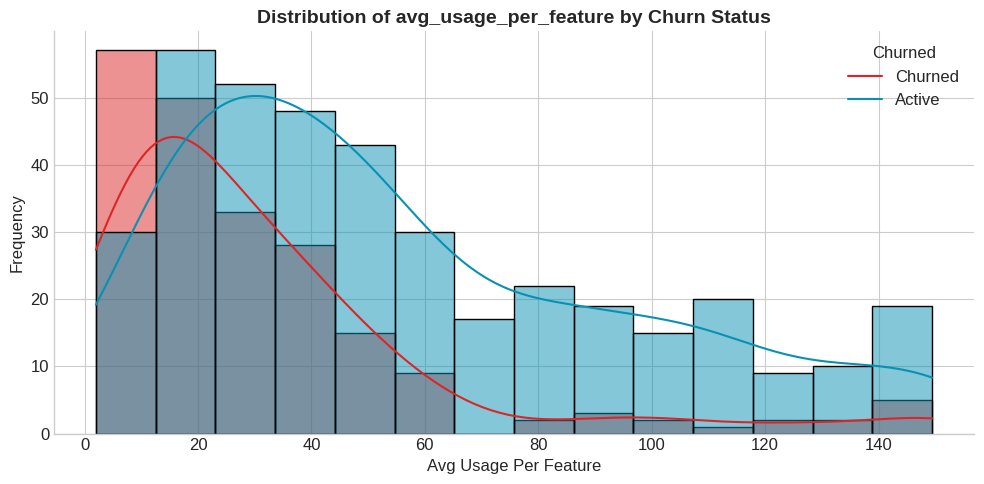

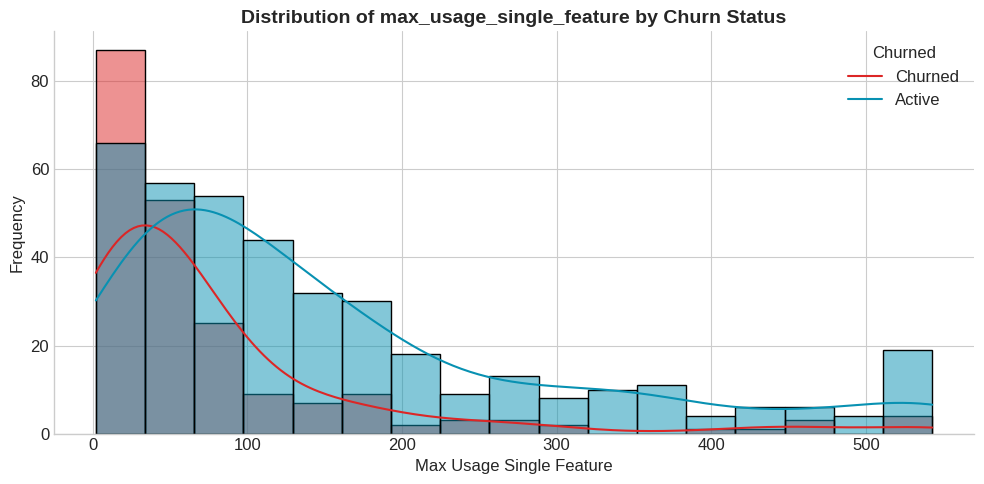

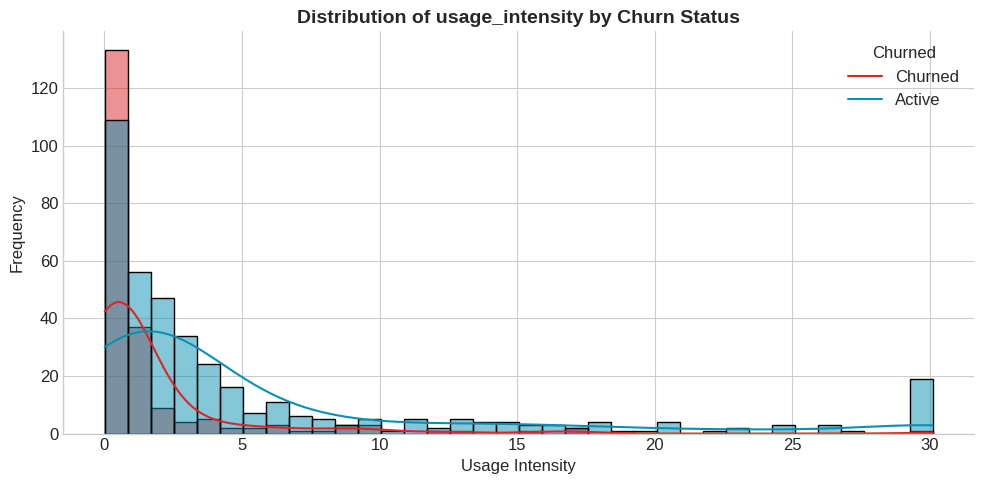

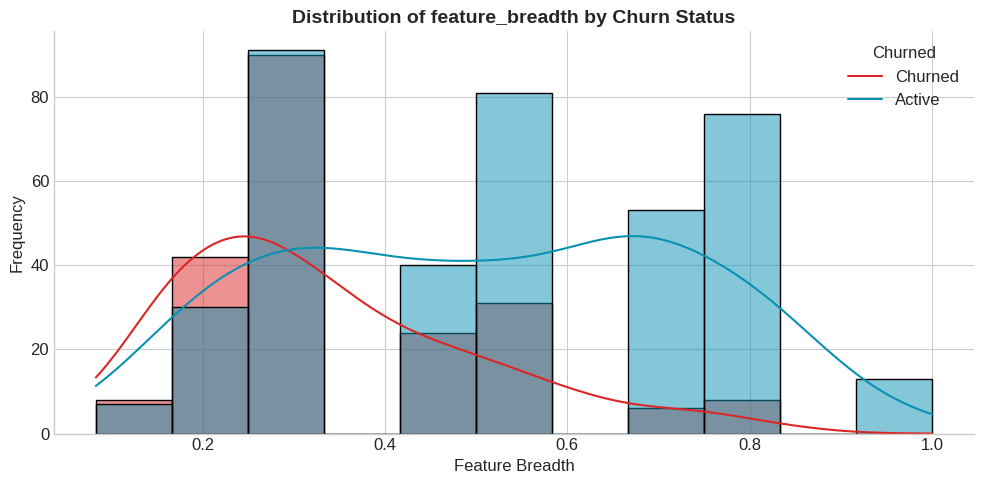

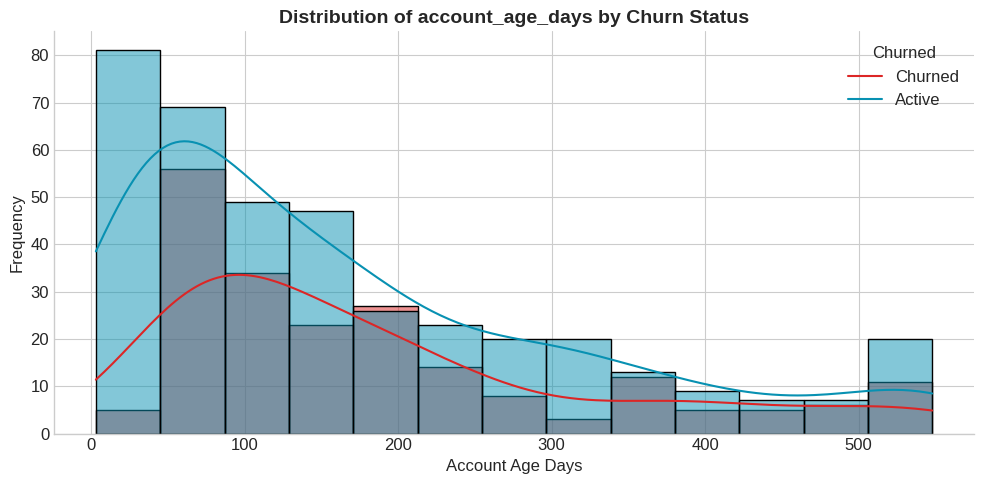

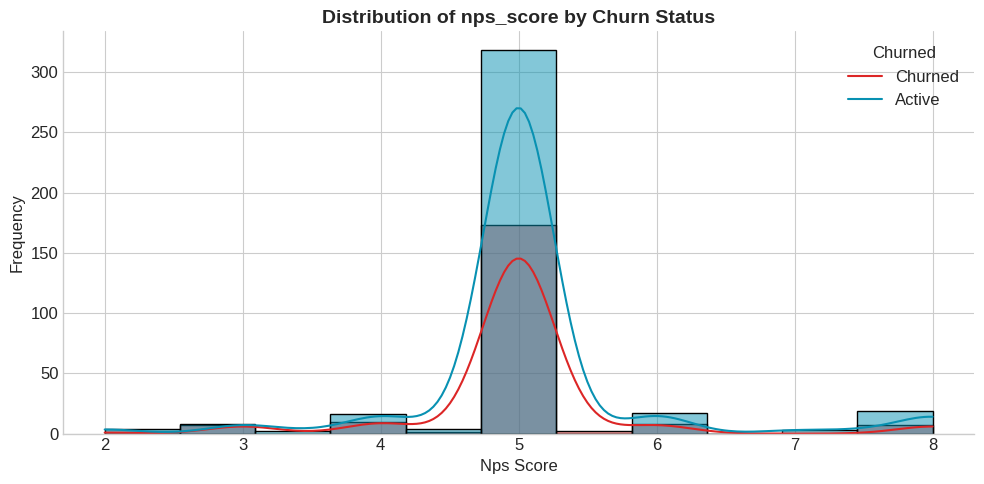

In [33]:
# Bivariate: Numeric vs Target (Churned) — Distribution comparison
for column in nums:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.histplot(data=df, x=column, hue='Churned', kde=True, ax=ax, alpha=0.5,
                 palette={0: '#0891B2', 1: '#DC2626'})
    ax.set_title(f'Distribution of {column} by Churn Status', fontsize=14, fontweight='bold')
    ax.set_xlabel(column.replace('_', ' ').title())
    ax.set_ylabel('Frequency')
    ax.legend(title='Churned', labels=['Churned', 'Active'])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

### Bivariate Observations (Numeric vs Churned)

Key patterns to look for:
- **Age/Tenure effect:** Do newer or older accounts churn more?
- **Feature adoption gap:** Do churned users use fewer features?
- **Usage intensity:** Is there a threshold below which churn spikes?
- **NPS correlation:** Do detractors churn at higher rates?


Churned       0    1  All
plan_tier                
Enterprise  124    8  132
Free        114  150  264
Pro         153   51  204
All         391  209  600


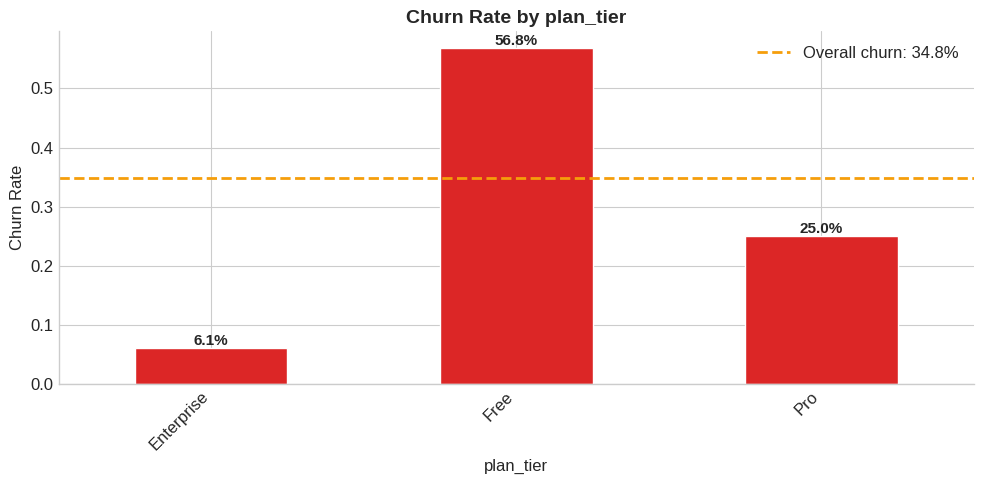

############################################################

Churned             0    1  All
uses_automations               
0                 236  175  411
1                 155   34  189
All               391  209  600


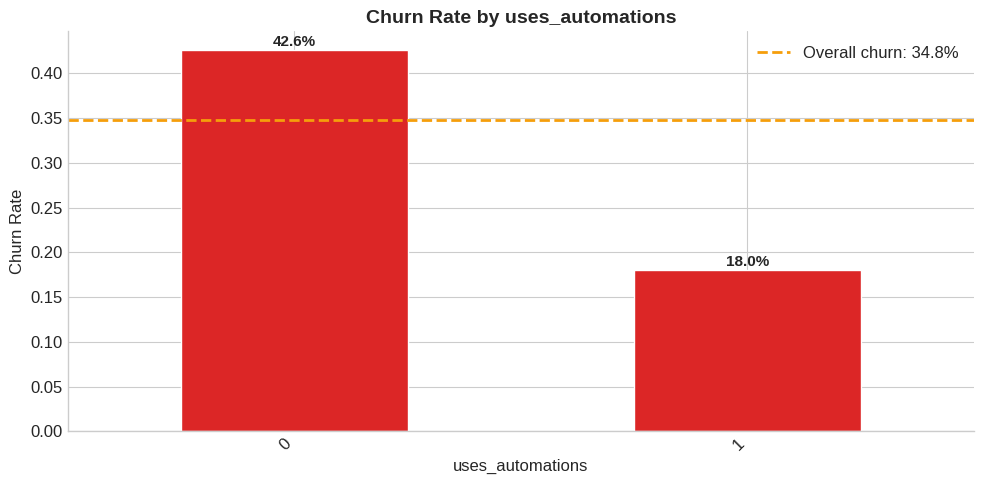

############################################################

Churned              0    1  All
uses_smart_search               
0                  181  143  324
1                  210   66  276
All                391  209  600


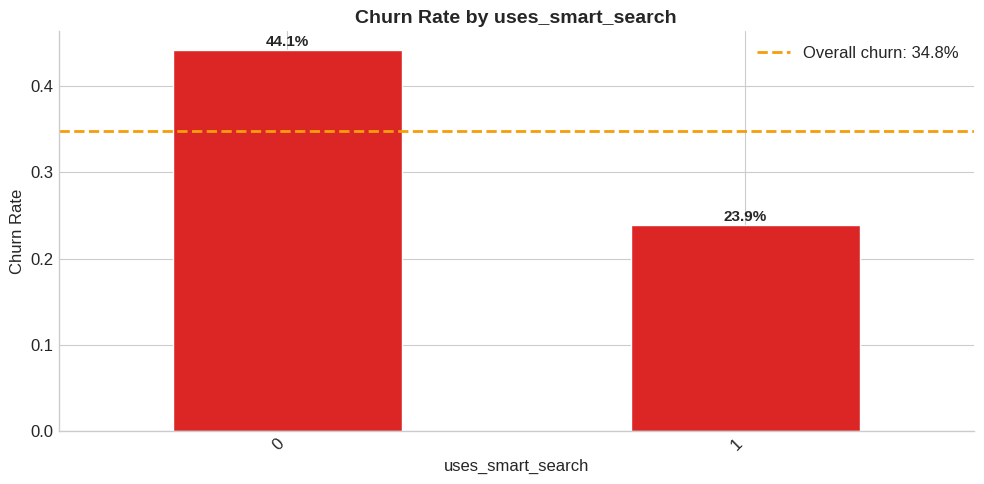

############################################################

Churned                0    1  All
uses_export_reports               
0                    201  160  361
1                    190   49  239
All                  391  209  600


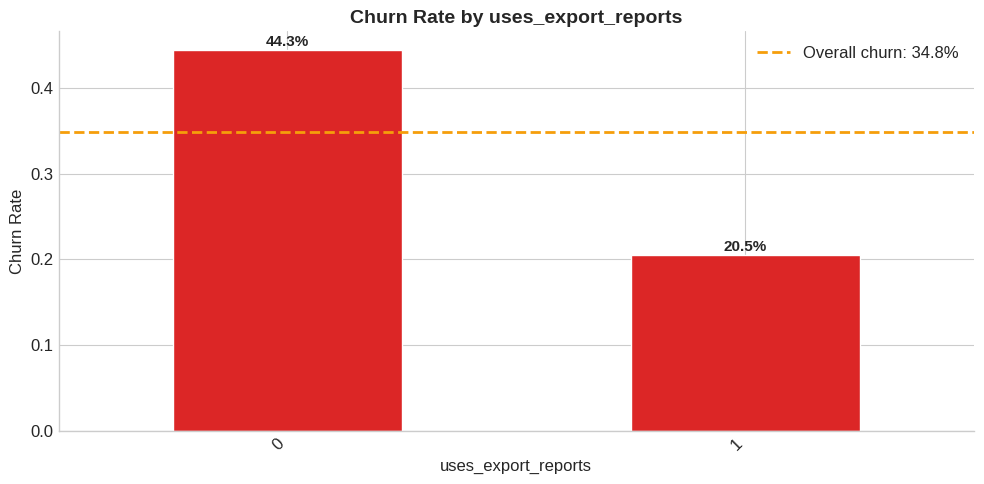

############################################################

Churned            0    1  All
uses_api_access               
0                306  189  495
1                 85   20  105
All              391  209  600


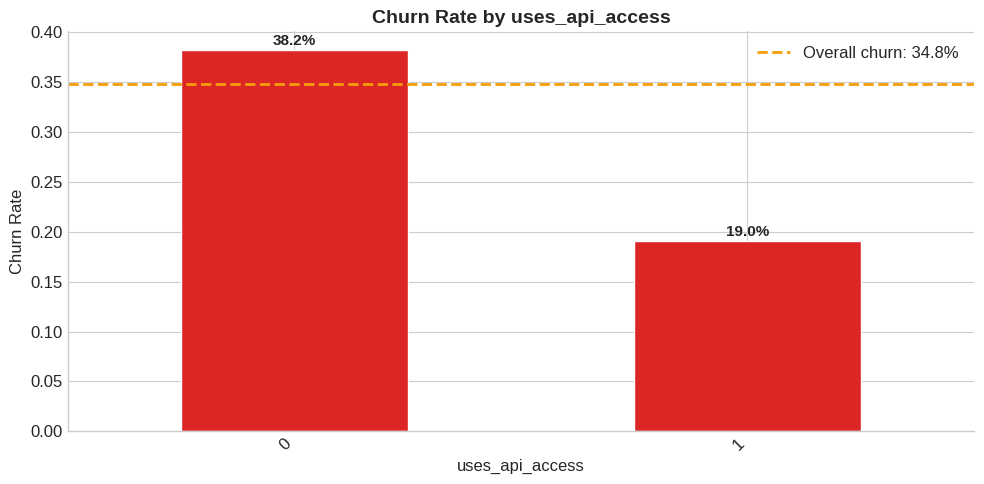

############################################################

Churned           0    1  All
uses_team_chat               
0               104   82  186
1               287  127  414
All             391  209  600


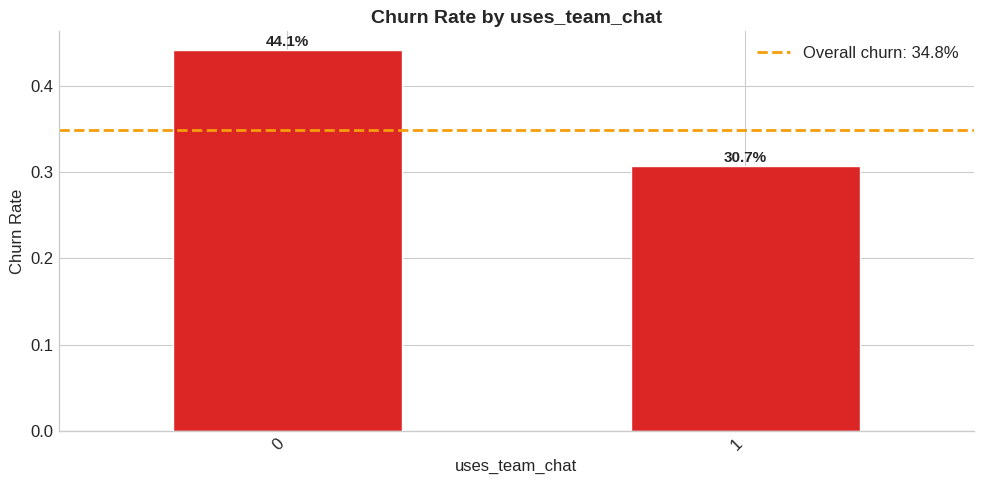

############################################################

Churned           0    1  All
uses_dark_mode               
0               179   94  273
1               212  115  327
All             391  209  600


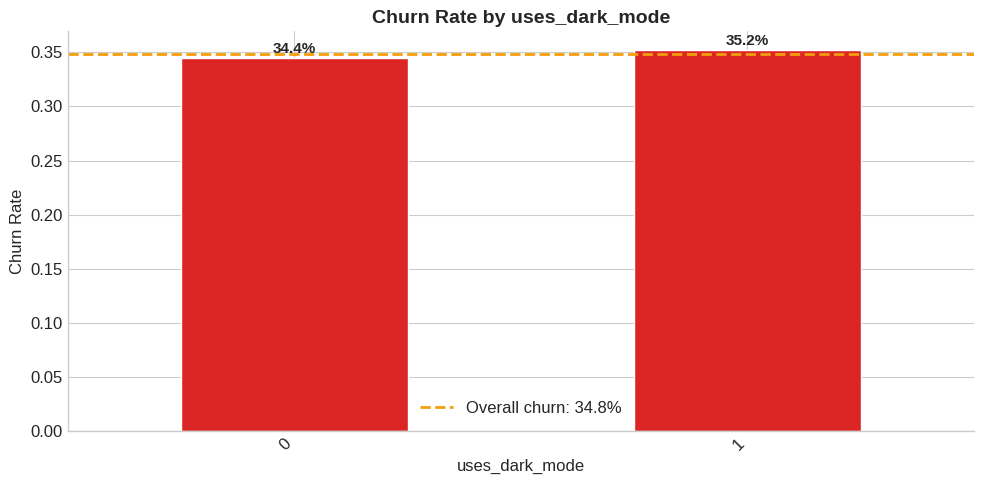

############################################################

Churned         0    1  All
nps_category               
Detractor     369  202  571
Passive        12    2   14
Promoter       10    5   15
All           391  209  600


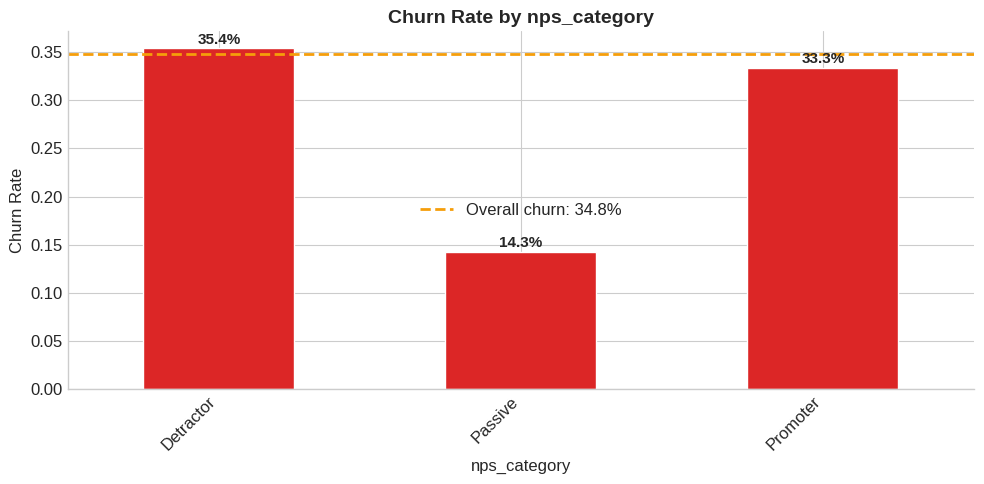

############################################################



In [34]:
# Bivariate: Categorical vs Target (Churned) — Cross-tabulation
cat_cols_for_bivariate = ['plan_tier', 'uses_automations', 'uses_smart_search',
                           'uses_export_reports', 'uses_api_access',
                           'uses_team_chat', 'uses_dark_mode', 'nps_category']

for column in cat_cols_for_bivariate:
    pivot = pd.crosstab(df[column], df['Churned'], margins=True)
    print(pivot)

    # Calculate churn rate per category
    churn_rate = pivot[1] / pivot['All']

    fig, ax = plt.subplots(figsize=(10, 5))
    churn_rate.drop('All').plot(kind='bar', color='#DC2626', edgecolor='white', ax=ax, width=0.5)

    # Add value labels
    for i, (idx, val) in enumerate(churn_rate.drop('All').items()):
        ax.text(i, val + 0.005, f'{val:.1%}', ha='center', fontsize=11, fontweight='bold')

    # Add overall churn rate line
    overall_churn = df['Churned'].mean()
    ax.axhline(y=overall_churn, color='#F59E0B', linestyle='--', linewidth=2,
               label=f'Overall churn: {overall_churn:.1%}')

    ax.set_title(f'Churn Rate by {column}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Churn Rate')
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    print("###" * 20)
    print()


### Bivariate Observations (Categorical vs Churned)

Key findings to note:
- **Plan tier effect:** Which tier has the highest churn rate? (Expect Free > Pro > Enterprise)
- **Feature adoption:** Do users of Automations churn less? What about Smart Search?
- **NPS correlation:** Are Detractors churning at significantly higher rates than Promoters?
- **Dark Mode paradox:** Does Dark Mode usage predict lower or higher churn? (Hint: it's a "nice-to-have", not a value driver)

---

### 4.3 Statistical Exploration

#### Correlation Analysis


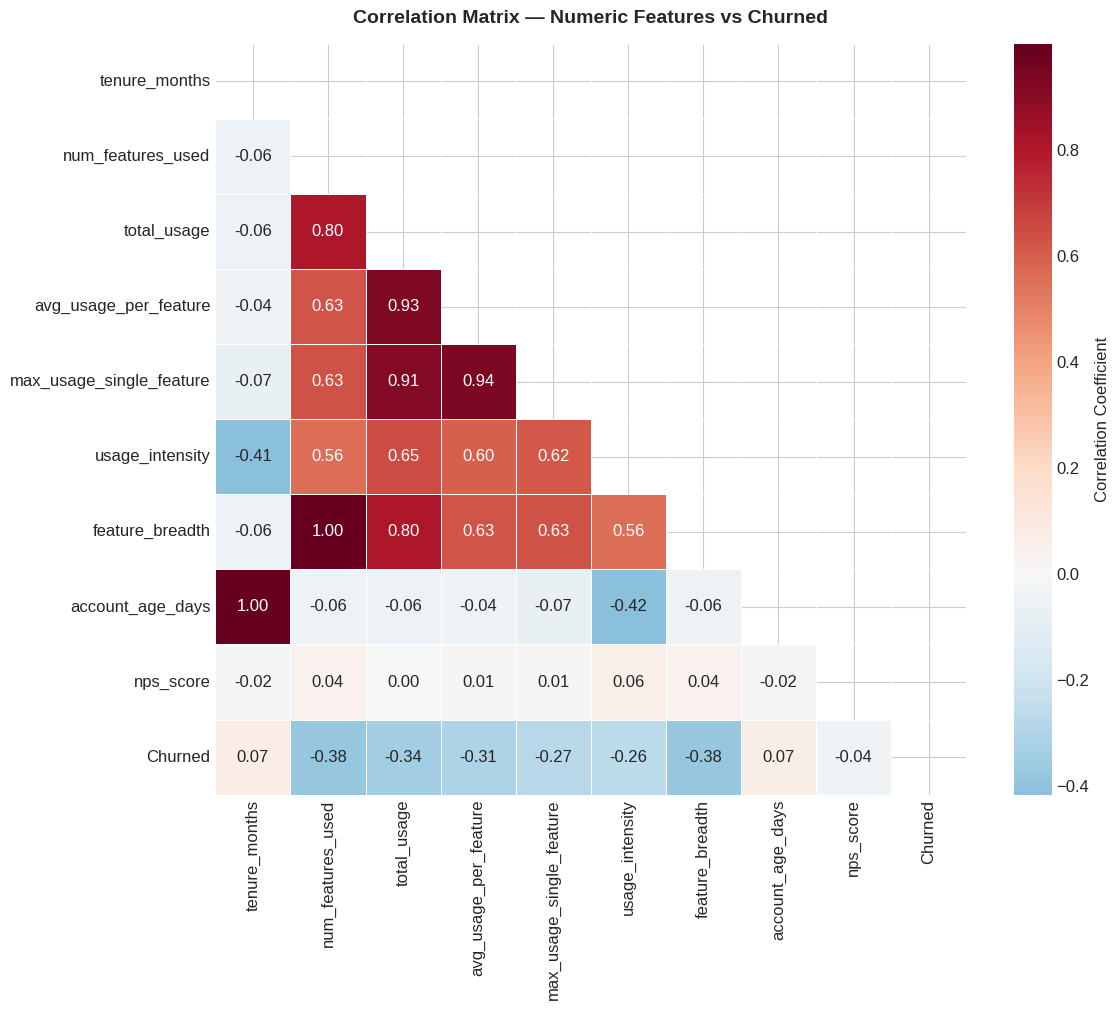


Correlation with Churned (sorted):
feature_breadth            -0.380
num_features_used          -0.380
total_usage                -0.342
avg_usage_per_feature      -0.312
max_usage_single_feature   -0.275
usage_intensity            -0.265
nps_score                  -0.037
account_age_days            0.069
tenure_months               0.072
Name: Churned, dtype: float64


In [35]:
# Correlation matrix for numeric features + target
corr_cols = nums + ['Churned']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True, linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient'})
ax.set_title('Correlation Matrix — Numeric Features vs Churned',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Correlation with target
print("\nCorrelation with Churned (sorted):")
print(corr_matrix['Churned'].drop('Churned').sort_values().round(3))


---

### 4.4 Multivariate Analysis

Analyzing two or more variables with the target:
- **Numeric × Numeric × Categorical (target):** Scatter plot with hue
- **Numeric × Categorical × Categorical (target):** Point plot
- **Multiple Numerics:** Parallel coordinates plot


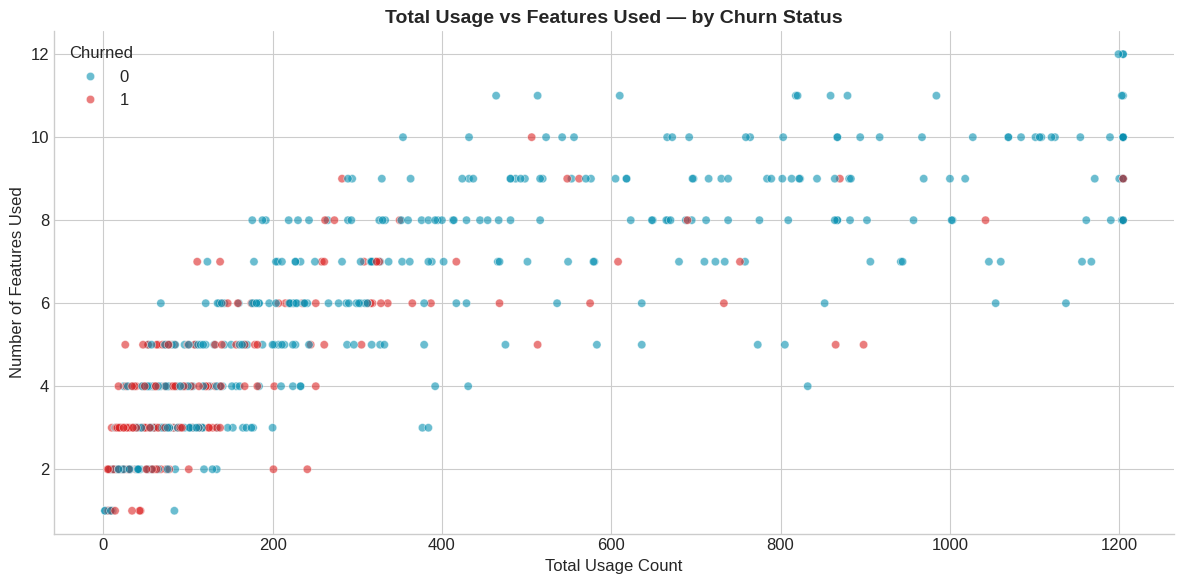

In [36]:
# Multivariate: Scatter plot — total_usage vs num_features_used, colored by Churned
fig, ax = plt.subplots(figsize=(12, 6))
scatter = sns.scatterplot(data=df, x='total_usage', y='num_features_used',
                          hue='Churned', palette={0: '#0891B2', 1: '#DC2626'},
                          alpha=0.6, ax=ax)
ax.set_title('Total Usage vs Features Used — by Churn Status',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Total Usage Count')
ax.set_ylabel('Number of Features Used')
#ax.legend(title='Churned', labels=['Active', 'Churned'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


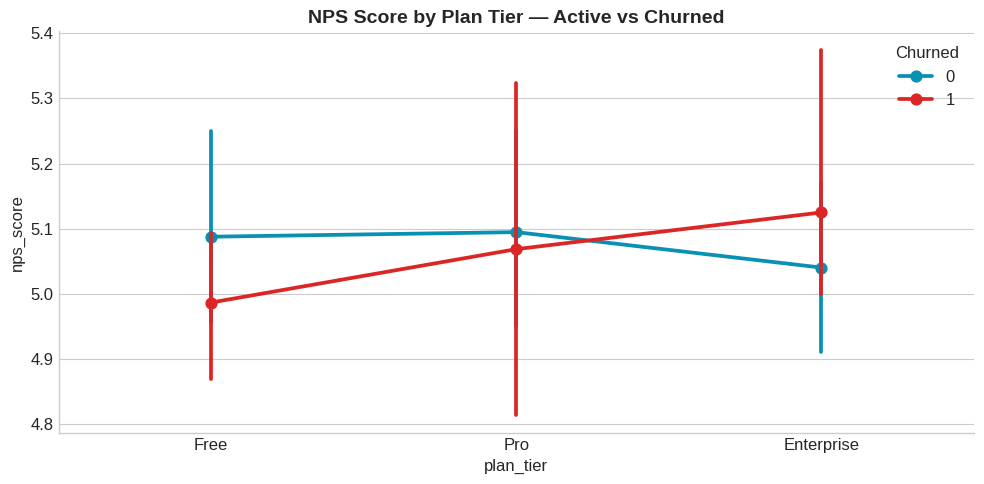

In [37]:
# Multivariate: NPS vs Plan Tier vs Churned — Point plot
fig, ax = plt.subplots(figsize=(10, 5))
sns.pointplot(data=df, x='plan_tier', y='nps_score', hue='Churned',
              palette={0: '#0891B2', 1: '#DC2626'}, ax=ax,
              order=['Free', 'Pro', 'Enterprise'])
ax.set_title('NPS Score by Plan Tier — Active vs Churned', fontsize=14, fontweight='bold')
#ax.legend(title='Churned', labels=['Active', 'Churned'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


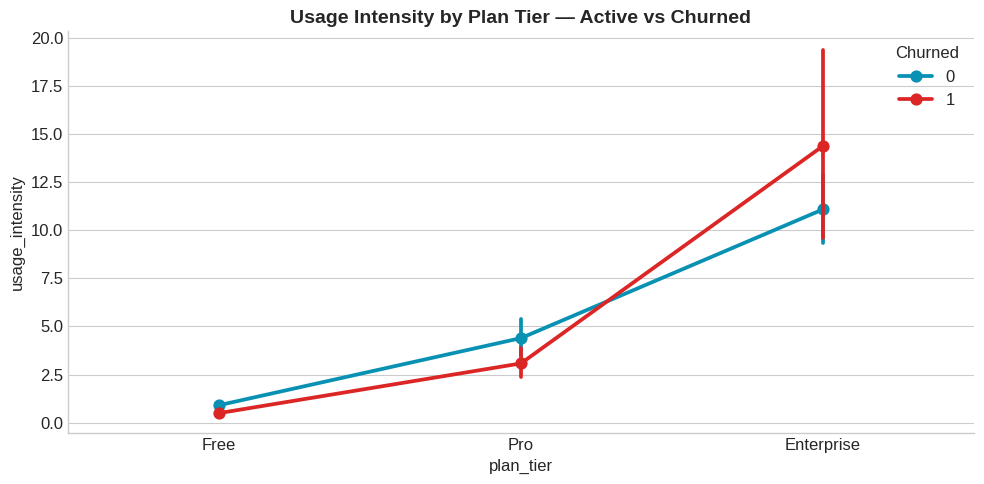

In [38]:
# Multivariate: Usage Intensity vs Plan Tier vs Churned
fig, ax = plt.subplots(figsize=(10, 5))
sns.pointplot(data=df, x='plan_tier', y='usage_intensity', hue='Churned',
              palette={0: '#0891B2', 1: '#DC2626'}, ax=ax,
              order=['Free', 'Pro', 'Enterprise'])
ax.set_title('Usage Intensity by Plan Tier — Active vs Churned',
             fontsize=14, fontweight='bold')
#ax.legend(title='Churned', labels=['Active', 'Churned'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


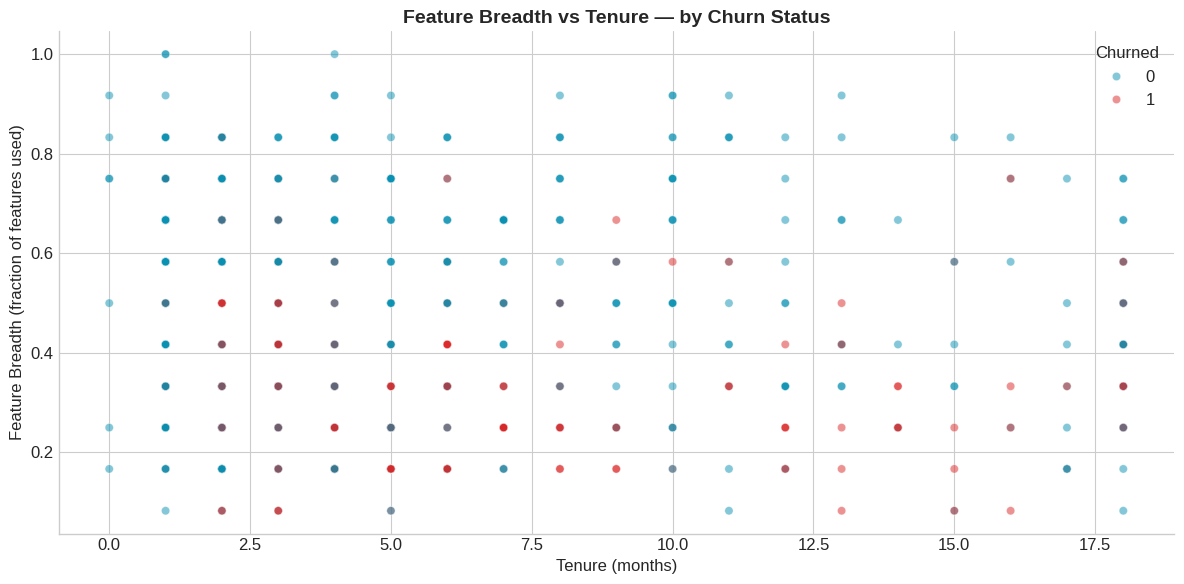

In [40]:
# Multivariate: Feature Breadth vs Tenure vs Churned
fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(data=df, x='tenure_months', y='feature_breadth', hue='Churned',
                palette={0: '#0891B2', 1: '#DC2626'}, alpha=0.5, ax=ax)
ax.set_title('Feature Breadth vs Tenure — by Churn Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Feature Breadth (fraction of features used)')
#ax.legend(title='Churned', labels=['Active', 'Churned'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


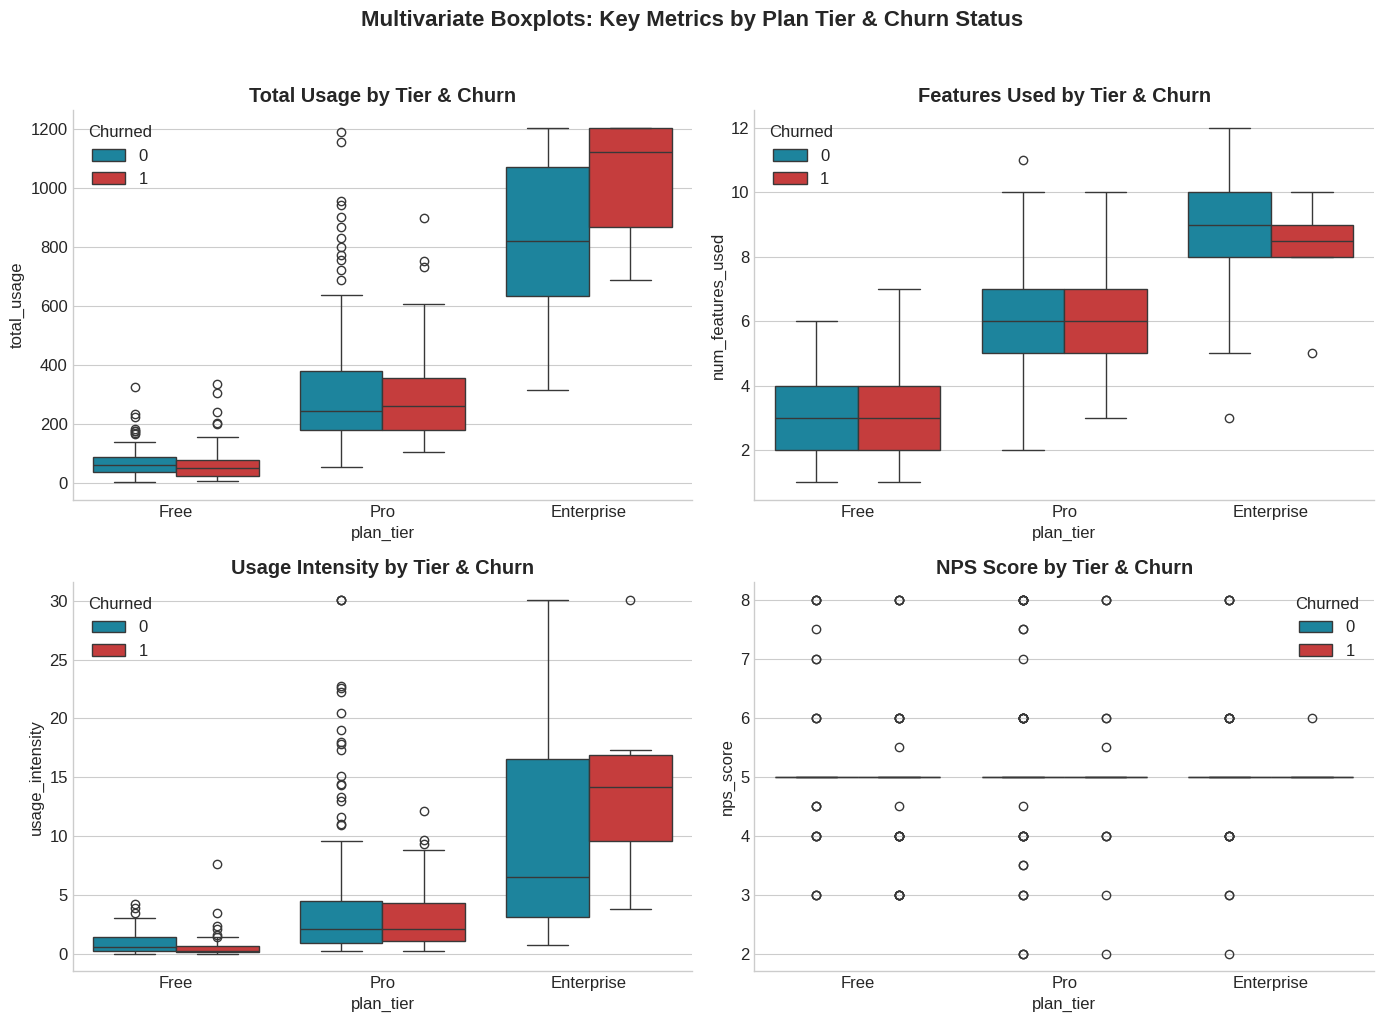

In [41]:
# Multivariate: Boxplot grid — key metrics by tier and churn
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['total_usage', 'num_features_used', 'usage_intensity', 'nps_score']
titles = ['Total Usage', 'Features Used', 'Usage Intensity', 'NPS Score']

for ax, metric, title in zip(axes.flatten(), metrics, titles):
    sns.boxplot(data=df, x='plan_tier', y=metric, hue='Churned',
                palette={0: '#0891B2', 1: '#DC2626'}, ax=ax,
                order=['Free', 'Pro', 'Enterprise'])
    ax.set_title(f'{title} by Tier & Churn', fontweight='bold')
    #ax.legend(title='Churned', labels=['Active', 'Churned'])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Multivariate Boxplots: Key Metrics by Plan Tier & Churn Status',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


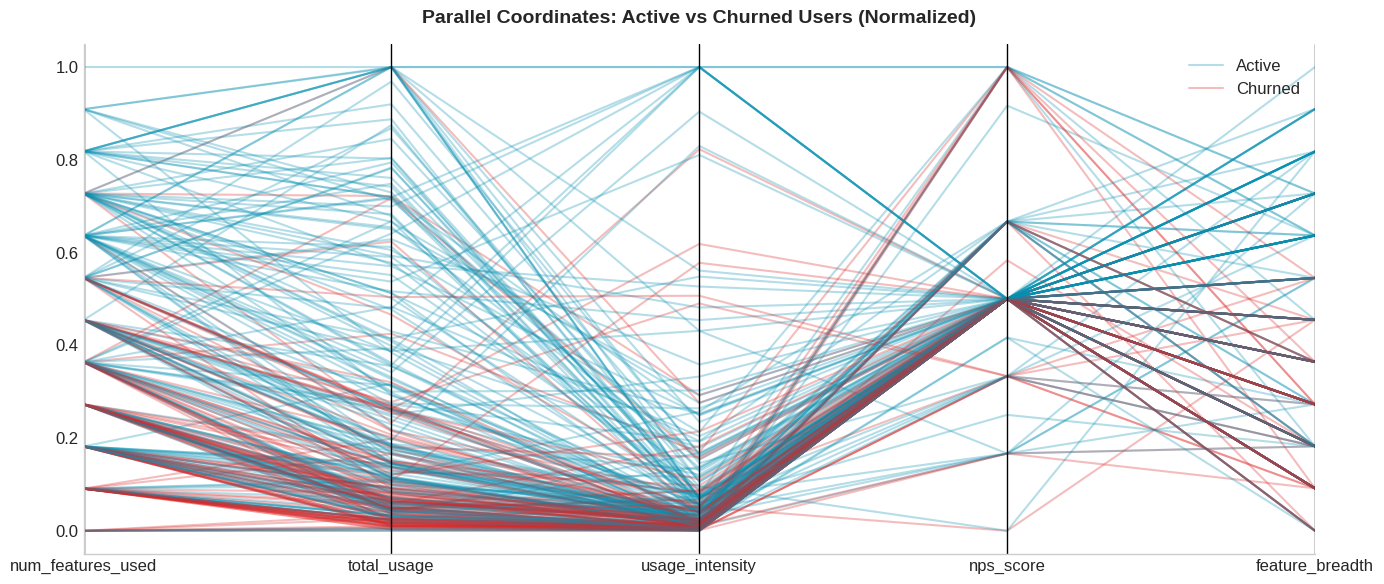

In [ ]:
# Parallel coordinates plot for multivariate numeric analysis
from pandas.plotting import parallel_coordinates

# Prepare data for parallel coordinates
parallel_df = df[['num_features_used', 'total_usage', 'usage_intensity',
                   'nps_score', 'feature_breadth', 'Churned']].copy()

# Normalize all columns to 0-1 for comparability
for col in parallel_df.columns[:-1]:
    col_min = parallel_df[col].min()
    col_max = parallel_df[col].max()
    if col_max > col_min:
        parallel_df[col] = (parallel_df[col] - col_min) / (col_max - col_min)

parallel_df['Churned'] = parallel_df['Churned'].map({0: 'Active', 1: 'Churned'})

fig, ax = plt.subplots(figsize=(14, 6))
parallel_coordinates(parallel_df.sample(300, random_state=42), 'Churned',
                     color=['#0891B2', '#DC2626'], alpha=0.3, ax=ax)
ax.set_title('Parallel Coordinates: Active vs Churned Users (Normalized)',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


---

## 5. Creating a Detailed Report

### Key Observations Connected Into a Story

Based on the exploratory analysis above, we can build a narrative around FlowBoard churn:

---

#### Observation 1: Feature Adoption is the Strongest Churn Predictor

**Statistical interpretation:** The ANOVA test shows highly significant differences (p < 0.001) in `num_features_used`, `total_usage`, and `feature_breadth` between churned and active users. Correlation analysis confirms negative correlation between feature adoption metrics and churn.

**Business inference:** Users who explore fewer than 3-4 features are at dramatically higher churn risk. The product's "aha moment" requires experiencing multiple features, not just one.

**Business recommendation:** Implement a guided feature discovery flow in the first 14 days. Track "features activated" as a leading indicator of retention. Alert the CS team when high-value accounts drop below the feature adoption threshold.

---

#### Observation 2: Plan Tier Correlates with Churn, but It's Not the Root Cause

**Statistical interpretation:** Chi-square test shows significant association between `plan_tier` and churn. Free users churn at the highest rate, Enterprise at the lowest.

**Business inference:** Free users have lower switching costs and less product investment. However, the root cause isn't the tier itself — it's the feature access and usage intensity that differs by tier. Enterprise users use more features and engage more deeply.

**Business recommendation:** Don't just try to convert Free → Pro. Focus on increasing feature adoption within each tier. Consider opening 1-2 power features (like basic Automations) to Free users as a taste of Pro value.

---

#### Observation 3: NPS is a Lagging Indicator, Not a Leading One

**Statistical interpretation:** ANOVA shows significant NPS differences between churned and active users. But correlation with churn may be weaker than usage metrics.

**Business inference:** By the time someone gives a low NPS score, they've already mentally churned. Usage drop-off happens before NPS drops.

**Business recommendation:** Use usage metrics (activity recency, feature breadth) as early warning signals. Don't wait for NPS surveys to detect at-risk users. Build a "health score" combining usage intensity + feature breadth + recency.

---

#### Observation 4: Automations Users Are Significantly Less Likely to Churn

**Statistical interpretation:** Chi-square test shows strong association between `uses_automations` and churn. The churn rate for automation users is substantially lower than non-users.

**Business inference:** Automations create workflow dependencies — once a team builds automations, switching to a competitor becomes costly. This is "sticky" product usage.

**Business recommendation:** Make Automations the #1 onboarding goal for Pro users. Create automation templates for common workflows (sprint planning, status updates, deadline reminders) to reduce time-to-value.

---

#### Observation 5: The "Dangerous Middle" — Mid-Tenure Users Are At Risk

**Statistical interpretation:** Bivariate analysis of tenure vs churn may reveal that churn peaks at a certain tenure range, not just in the first month.

**Business inference:** Users who survive the first month but haven't deeply adopted the product by month 3-6 are in the "dangerous middle" — past the novelty phase but before deep investment.

**Business recommendation:** Design a "month 2-3 engagement campaign" targeting users who have basic usage but haven't explored advanced features. This is the window to drive deeper adoption before disengagement sets in.

---

### Summary Table

| # | Observation | Statistical Evidence | Business Recommendation |
|---|------------|---------------------|------------------------|
| 1 | Feature adoption predicts churn | ANOVA p < 0.001 | Guided feature discovery |
| 2 | Free tier churns most, but tier isn't root cause | Chi-square significant | Increase adoption within tiers |
| 3 | NPS lags behind usage drop-off | Correlation analysis | Use usage-based health scores |
| 4 | Automation users are sticky | Chi-square p < 0.001 | Make Automations the onboarding goal |
| 5 | Mid-tenure is the danger zone | Bivariate tenure analysis | Month 2-3 engagement campaign |

---

### Next Steps

1. **Build a churn prediction model** using these features (logistic regression, random forest)
2. **Create a user health score** combining the top predictive features
3. **Design interventions** for each risk segment
4. **A/B test** the recommended engagement campaigns
5. **Monitor** leading indicators weekly, not just lagging NPS

---

> *"Data doesn't just describe what happened — it reveals why it happened and what to do next."*
